![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:

    Our current process is a manual review performed by loan officers. This process has a multitude of issues, first among these is that each loan officer has their own logic for approval in loans. This leads to a haphazard collection of loans each with a different potential chance of being a mistake. Plus the manual review by loan officers can allow for stereotypes and personal biases to intrude and discriminate against our customers. Another major issue in bandwidth of loans that can be processed. Each manual review can take an appreciable amount of time, so to expand the number of loans we can handle we would need to hire more and more loan officers which leads to a higher risk of hiring poor candidates and increases the potential for inconsistency in treatment for each loan. The final issue is that of onboarding new loan officers, as they will likely perform worse as they learn what makes a good loan and what loans will fail, and if we have them train with one of our current loan officers, then they may inherit biases and the same inconsistencies as their mentors. The key stakeholders for our loan approval system, are the company which wants to maximize our profits and our trust among the partner base for providing a working and superior service, our bank partners who want a modern and superior system but still likely want some control over the process, the loan officers who do not wish to be made unemployed and wish for a certain level in understand what the machine is doing, and those who are seeking legitimate loans who want to get their loan aprpoved and likely don't want to have an opaque machine do all the action. So we should be careful in moving over to a data driven approach to loan approval. The two forms of error that arise from our process are the denial of loans to those who are creditworthy, which cost $8000 in lost profit and the approval of loans to those who default on them, which costs the bank $50,000. The defaulted loans cost the company a much higher amount of money, so using a data-driven approach we can focus on reducing those errors, which will also improve our trust among customers that we provide good loans. The data-driven appraoch can take two forms where we have the model directly classify applicants into a category, while regression based approaches can instead give a score to each applicant. I suggest that we should use classification based approach for our system. A classification based approach should be able to improve on the results of the officers who the banks currently use. It is important to the stakeholders that we do keep a human in the loop for approving the loans, which will satisfy the applicants as they can discuss with a human, satisfy the loan officers, as they get a useful tool without being replaced, and ensures that the banks while still needing to keep their officers around, do want their customers to be satisfied, and they want to ensure that they have a representative of their interests in the approval process. Classification models can allow for a better understanding of key decision points that can be shared with the banks to help their loan officers improve and create a standard for training

2. Define your modeling goals and success criteria:
    
    The primary goals of the model should be to minimize defaulted loans and then to minimize the number of incorrectly classified creditworthy applicants. The first one suggests using the metric of precision, which is the number of true positives out of the set of all predicted positives, which will help reduce the number of false positives. Another metric should use the specific value difference between the false positive at $50,000 and the false negative at $8,000. This calls for a custom metric that will be labeled Total Financial Loss, which should be minimized. It would be calculated by the formula FP * 50000 + FN * 8000. This metric will ensure that the precision optimization doesn't push for everyone to be rejected. The main criteria for success is to have a Total Finanical Loss of less than $100,000 per 100 people


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [2]:
# Imports
import pandas as pd
import numpy as np
from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# EDA Code Here - Create New Cells As Needed
df_loan = pd.read_csv('financial_loan_data.csv')

In [4]:
df_loan.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [5]:
df_loan.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  str    
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  str    
 4   EducationLevel              19099 non-null  str    
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  str    
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  str    
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     20000 non-null

### On the missing values

The features with the highest numbers of missed values are:
- EducationLevel
- MaritalStatus
- SavingsAccountBalance

These missing values mi not be random and can represent meaningful information to the models.

These missing values should be handled based on which type of feature they are:
- Numerical features: imputed using median values to reduce sensitivity to outliers
- Categorical features: imputed using mode category

This ensures that missing values are handled consistently and will prevent data leakage between training and test sets.

In [6]:
print('Annual Income', df_loan['AnnualIncome'].unique())
print('Employment Status', df_loan['EmploymentStatus'].unique())
print('Education Level', df_loan['EducationLevel'].unique())
print('Marital Status', df_loan['MaritalStatus'].unique())
print('Home Ownership Status', df_loan['HomeOwnershipStatus'].unique())
print('Bankruptcy History', df_loan['BankruptcyHistory'].unique())
print('Loan Purpose', df_loan['LoanPurpose'].unique())


Annual Income <ArrowStringArray>
[ '$39,948.00',  '$39,709.00',  '$40,724.00',  '$69,084.00', '$103,264.00',
 '$178,310.00',  '$51,250.00',  '$97,345.00', '$116,841.00',  '$40,615.00',
 ...
  '$41,949.00',  '$27,335.00',  '$77,443.00', '$147,351.00',  '$96,264.00',
  '$60,433.00',  '$34,282.00',  '$30,180.00',  '$41,025.00',  '$53,227.00']
Length: 17516, dtype: str
Employment Status <ArrowStringArray>
['Employed', 'Self-Employed', 'Unemployed']
Length: 3, dtype: str
Education Level <ArrowStringArray>
['Master', 'Associate', 'Bachelor', 'High School', nan, 'Doctorate']
Length: 6, dtype: str
Marital Status <ArrowStringArray>
['Married', 'Single', nan, 'Divorced', 'Widowed']
Length: 5, dtype: str
Home Ownership Status <ArrowStringArray>
['Own', 'Mortgage', 'Rent', 'Other']
Length: 4, dtype: str
Bankruptcy History <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Loan Purpose <ArrowStringArray>
['Home', 'Debt Consolidation', 'Education', 'Other', 'Auto']
Length: 5, dtype: str


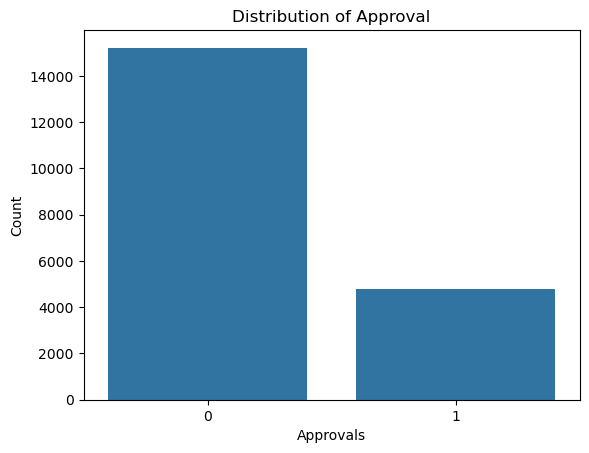

In [7]:
approval_counts = df_loan['LoanApproved'].value_counts()

# Visualize (use the counts object)
X = approval_counts.index
y = approval_counts.values

# Code for plot provided
sns.barplot(x=X, y=y)
plt.xlabel('Approvals')
plt.ylabel('Count')
plt.title("Distribution of Approval");

In [ ]:
# TEMPORARY CLEAN for exploration
df_loan['AnnualIncome_clean'] = (
    df_loan['AnnualIncome']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

features = [
    'CreditScore',
    'AnnualIncome_clean',
    'DebtToIncomeRatio',
    'LoanAmount'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        data=df_loan,
        x='LoanApproved',
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} vs LoanApproved')

plt.tight_layout()
plt.show()

These charts suggest that debt to income ratio has little impact on the approval of loans. There is also major overlap in amount and credit score, though both do have clear trends. A higher credit score and lower amount requested are both common features of the approved loans. The largest gap is that between the Annual Income of those who got approval as compared to those who didn't where there is no overlap in the bottom 75% of those rejected and the top 25% in income

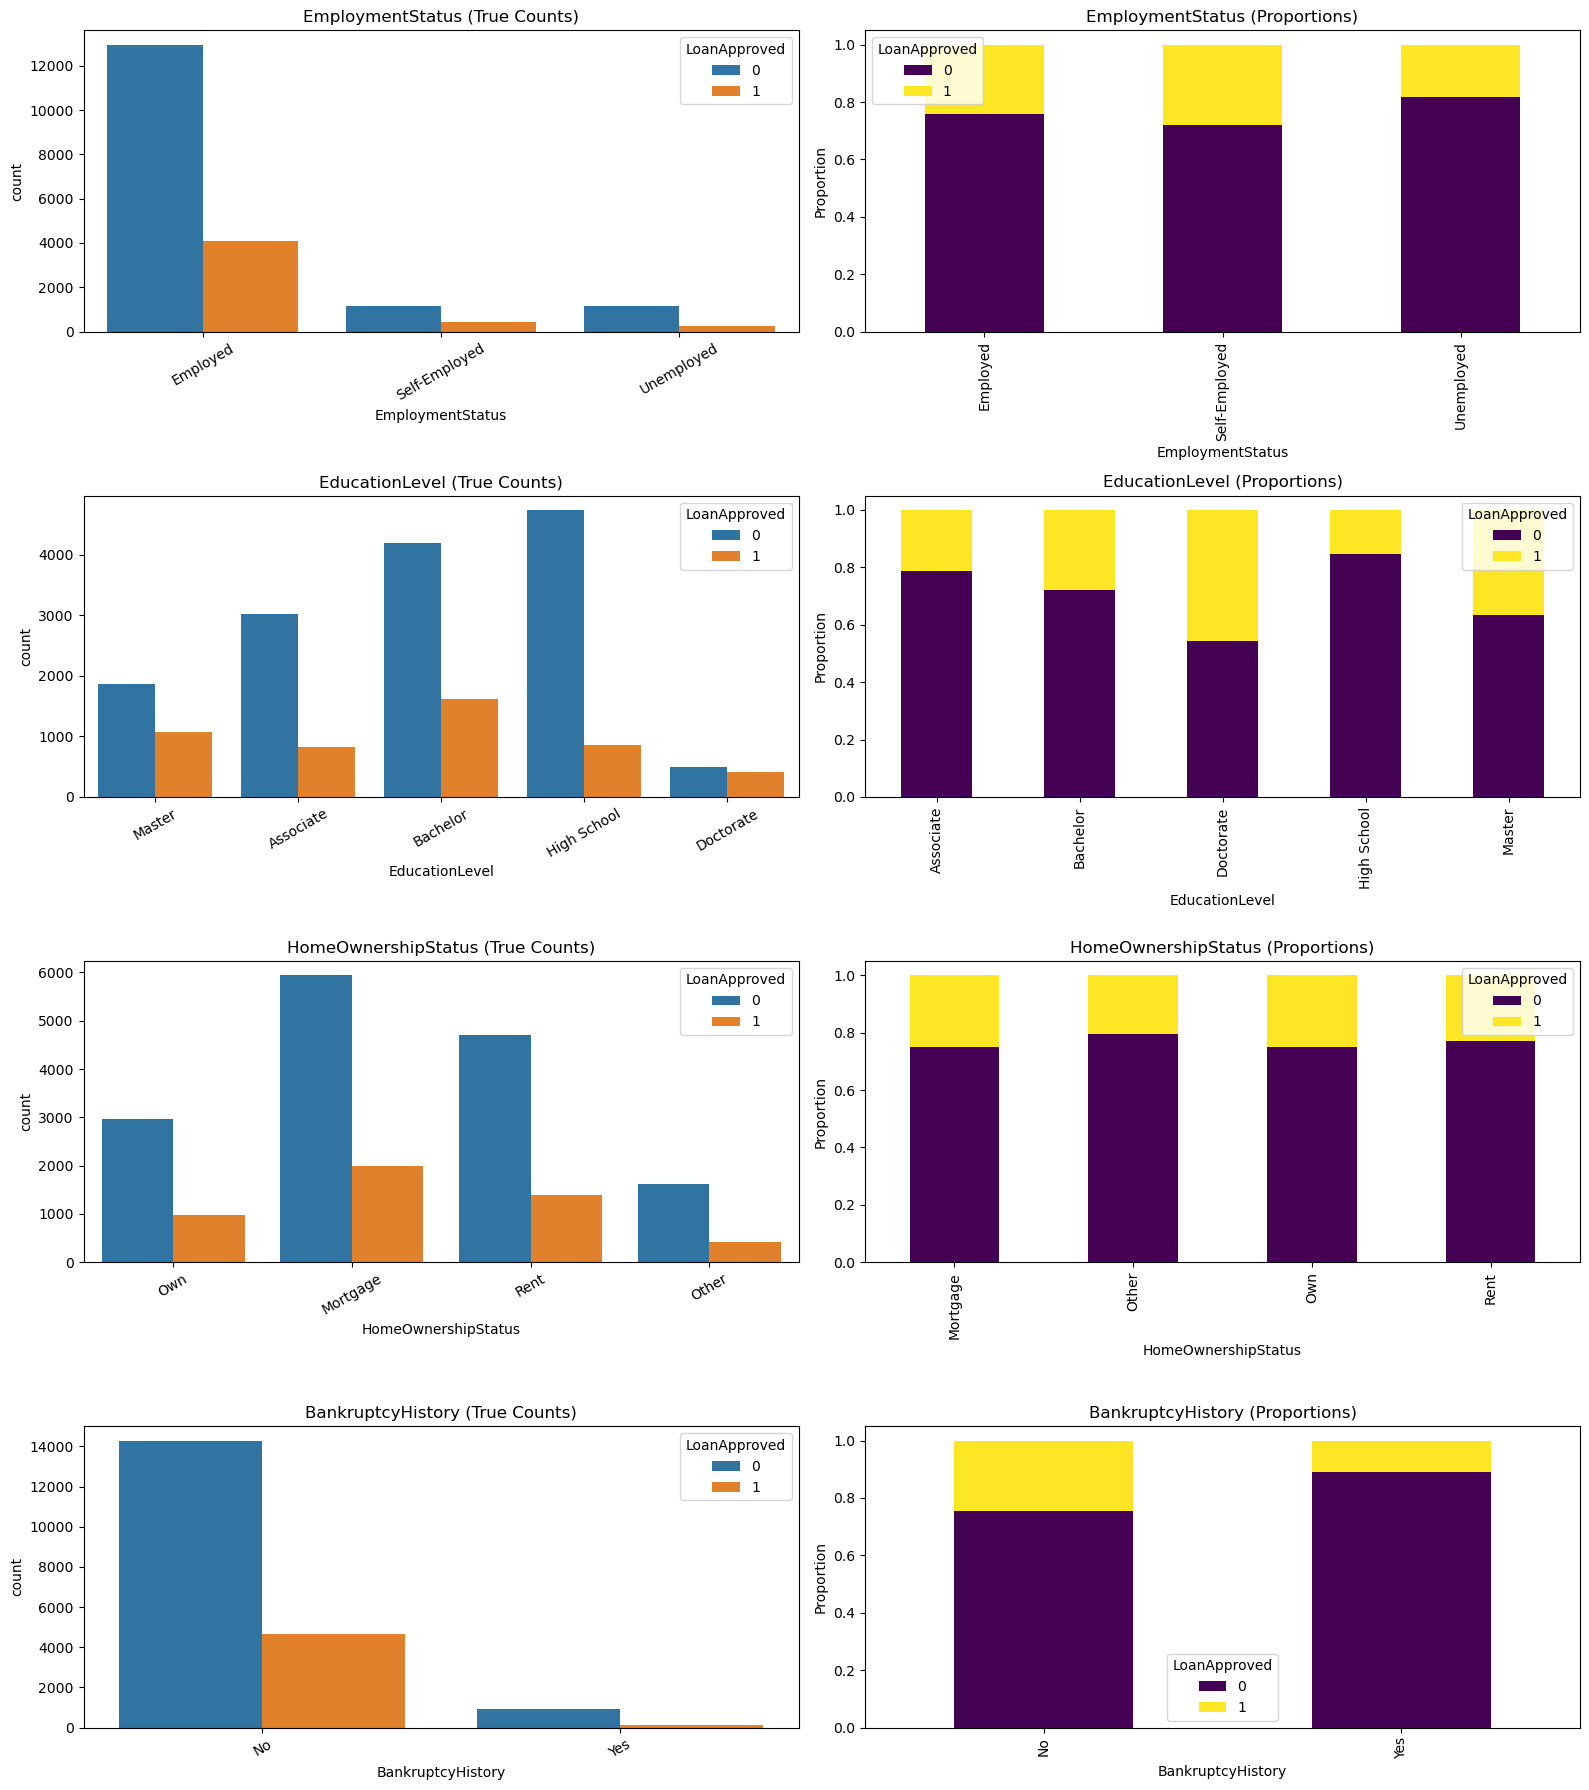

In [ ]:
cat_features = [
    'EmploymentStatus',
    'EducationLevel',
    'HomeOwnershipStatus',
    'BankruptcyHistory'
]

fig, axes = plt.subplots(len(cat_features), 2, figsize=(16, 18))

for i, col in enumerate(cat_features):

    # STANDARD
    sns.countplot(
        data=df_loan,
        x=col,
        hue='LoanApproved',
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{col} (True Counts)')
    axes[i, 0].tick_params(axis='x', rotation=30)

    # NORMALIZED
    prop_df = (
        df_loan.groupby(col)['LoanApproved']
        .value_counts(normalize=True)
        .unstack()
        .fillna(0)
    )

    prop_df.plot(
        kind='bar',
        stacked=True,
        ax=axes[i, 1],
        colormap='viridis'
    )

    axes[i, 1].set_title(f'{col} (Proportions)')
    axes[i, 1].set_ylabel('Proportion')
    axes[i, 1].legend(title='LoanApproved')

plt.tight_layout()
plt.show()

Higher levels education and not having a history of bankruptcy both have much higher proportions of loan approval. An interesting thing is that the self-employed have a higher rate approval than those who are in standard employment. Home ownership status on the other hand seems to have minimal impact in the proportion of those who get loans.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision

In [ ]:
# Data Prep Code Here - Create New Cells As Needed
target = 'LoanApproved'

numeric_features = [
    'Age',
    'AnnualIncome',
    'CreditScore',
    'Experience',
    'LoanAmount',
    'LoanDuration',
    'NumberOfDependents',
    'MonthlyDebtPayments',
    'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines',
    'NumberOfCreditInquiries',
    'DebtToIncomeRatio',
    'PreviousLoanDefaults',
    'PaymentHistory',
    'LengthOfCreditHistory',
    'SavingsAccountBalance',
    'CheckingAccountBalance',
    'TotalAssets',
    'TotalLiabilities',
    'MonthlyIncome',
    'UtilityBillsPaymentHistory',
    'JobTenure',
    'NetWorth',
    'BaseInterestRate',
    'InterestRate',
    'MonthlyLoanPayment',
    'TotalDebtToIncomeRatio'
]

ordinal_features = ['EducationLevel']

categorical_features = [
    'EmploymentStatus',
    'MaritalStatus',
    'HomeOwnershipStatus',
    'BankruptcyHistory',
    'LoanPurpose'
]

In [ ]:
df_loan['AnnualIncome'] = (
    df_loan['AnnualIncome']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
) # We need to properly clean this up

In [ ]:

numeric_transformer = Pipeline(steps=[
    # This will fill out the numbers by their median value. This will prevent the model from catching onto outliers caused by imputing them to a default not based in the data
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline(steps=[
    # Similar to numeric
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[[
        'High School',
        'Associate',
        'Bachelor',
        'Master',
        'Doctorate'
    ]]))
])

categorical_transformer = Pipeline(steps=[
    # This here is similar again
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

The ColumnTransformer allowed for each of the different column groups to be written in their own pipleine and united together in one. The numerical features were imputed with the median to not create major features for the model to latch onto, and was standardized so that feature magnitude didn't throw off any models. Education level was the only feature that really made since to treat as an ordinal based on the exploration due to its heavy influence in approval. The categorical variables were imputed using the modal category, for similar reasons to the numeric features and then were encoded using OneHotEncoding. This makes the data useful with all the models I am planning to use while preventing data leakage, which could mess with our models and the later evaluation of the model

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [ ]:
#  Modeling Code Here - Create New Cells as Needed
X = df_loan.drop(columns=['LoanApproved'])
y = df_loan['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000
    ))
])

logistic_pipeline.fit(X_train, y_train)

forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
def financial_loss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * 50000 + fn * 8000

# NEGATIVE because sklearn maximizes scores
financial_scorer = make_scorer(financial_loss, greater_is_better=False)

In [ ]:
# Basic model outcomes:
xgb_train_score =  xgb_pipeline.score(X_train, y_train)
logistic_train_score = logistic_pipeline.score(X_train, y_train)
forest_train_score = forest_pipeline.score(X_train, y_train)

xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring=financial_scorer)
logistic_cv_scores = cross_val_score(logistic_pipeline, X_train, y_train, cv=5, scoring=financial_scorer)
forest_cv_scores = cross_val_score(forest_pipeline, X_train, y_train, cv=5, scoring=financial_scorer)

print(f"Training and Cross Validation Performance Comparison of Models")
print(f"XGB: Train - {xgb_train_score:.3f}, CV - {xgb_cv_scores.mean():.3f}")
print(f"Logistic: Train - {logistic_train_score:.3f}, CV - {logistic_cv_scores.mean():.3f}")
print(f"Forest: Train - {forest_train_score:.3f}, CV - {forest_cv_scores.mean():.3f}")

Training and Cross Validation Performance Comparison of Models
XGB: Train - 1.000, CV - -3975200.000
Logistic: Train - 0.967, CV - -2970000.000
Forest: Train - 1.000, CV - -5136800.000


In [ ]:
models = {
    "XGB": xgb_pipeline,
    "Logistic": logistic_pipeline,
    "RandomForest": forest_pipeline
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    loss = financial_loss(y_test, y_pred)
    
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"Total Financial Loss: ${loss:,.0f}")


XGB
[[2909   74]
 [ 112  905]]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2983
           1       0.92      0.89      0.91      1017

    accuracy                           0.95      4000
   macro avg       0.94      0.93      0.94      4000
weighted avg       0.95      0.95      0.95      4000

Total Financial Loss: $4,596,000

Logistic
[[2923   60]
 [  89  928]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2983
           1       0.94      0.91      0.93      1017

    accuracy                           0.96      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.96      0.96      0.96      4000

Total Financial Loss: $3,712,000

RandomForest
[[2894   89]
 [ 210  807]]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      2983
           1       0.90      0.79      0.84      1017

    ac

In [20]:
# Logistic Regression Parameters
param_dist_logistic = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'preprocessor__num__imputer__strategy': ['mean', 'median']
}



In [ ]:
grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_dist_logistic,
    cv=3,             # 3-fold cross-validation
    scoring=financial_scorer, 
    random_state=42,
    n_jobs=-1,        # Use all available cores
    verbose=1
)

grid_search.fit(X_train, y_train)

best_estimator = grid_search.best_estimator_

print(f"Best Cost (CV Score): ${abs(grid_search.best_score_):,.2f}")
print(f"Best Params: {grid_search.best_params_}\n")

NameError: name 'GridSearchCV' is not defined

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements